<a href="https://colab.research.google.com/github/kaii0802/CS-5530---Kai-Son/blob/main/student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q2 - Students Performance: ingest, preprocess, and five visualizations

Three-stage workflow: **ingest -> process -> analyze**.

| Stage | What happens | Output |
|---|---|---|
| 1. Ingest | load the raw CSV, run integrity checks | DataFrame |
| 2. Process | clean names/types, handle missing values, validate ranges, add `overall_avg` | `data/processed/students_clean.csv` |
| 3. Analyze | five figures (800x600 px, 300 DPI) + a 5-8 sentence interpretation each | `figures/*.png`, `reports/findings.md` |

This notebook lives in `q2_student_performance/src/`; every path below is resolved relative to the `q2_student_performance/` folder.

In [ ]:
%cd /content
!git clone https://github.com/kaii0802/CS-5530---Kai-Son.git

/content
Cloning into 'CS-5530---Kai-Son'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 26 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 19.33 KiB | 3.87 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [ ]:
from pathlib import Path
import re

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from matplotlib.lines import Line2D
from PIL import Image as PILImage
from scipy import stats

# The notebook lives in <question>/src/, so the question folder is its parent.
ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
RAW_CSV = ROOT / "data" / "raw" / "StudentsPerformance.csv"
CLEAN_CSV = ROOT / "data" / "processed" / "students_clean.csv"
FIG_DIR = ROOT / "figures"
REPORT = ROOT / "reports" / "findings.md"
for folder in (CLEAN_CSV.parent, FIG_DIR, REPORT.parent):
    folder.mkdir(parents=True, exist_ok=True)

## Stage 1 - Ingest

Load the raw CSV and check that the expected columns are present, then record basic data-quality facts
(row count, dtypes, missing values, duplicates). The raw file is never modified.

In [ ]:
EXPECTED_COLUMNS = [
    "gender", "race/ethnicity", "parental level of education", "lunch",
    "test preparation course", "math score", "reading score", "writing score",
]

def load_raw() -> pd.DataFrame:
    df = pd.read_csv(RAW_CSV)
    missing_cols = set(EXPECTED_COLUMNS) - set(df.columns)
    if missing_cols:
        raise ValueError(f"Raw file is missing expected columns: {sorted(missing_cols)}")
    return df

def describe_raw(df: pd.DataFrame) -> dict:
    """Facts recorded in the report's data-quality section."""
    return {
        "rows": len(df),
        "cols": df.shape[1],
        "dtypes": df.dtypes.astype(str).to_dict(),
        "missing_per_column": df.isna().sum().to_dict(),
        "duplicate_rows": int(df.duplicated().sum()),
    }


raw = load_raw()
raw_info = describe_raw(raw)
print(raw_info)
raw.head()

{'rows': 1000, 'cols': 8, 'dtypes': {'gender': 'str', 'race/ethnicity': 'str', 'parental level of education': 'str', 'lunch': 'str', 'test preparation course': 'str', 'math score': 'int64', 'reading score': 'int64', 'writing score': 'int64'}, 'missing_per_column': {'gender': 0, 'race/ethnicity': 0, 'parental level of education': 0, 'lunch': 0, 'test preparation course': 0, 'math score': 0, 'reading score': 0, 'writing score': 0}, 'duplicate_rows': 0}


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Stage 2 - Preprocess

Cleaning rules, applied in order:

1. rename columns to snake_case; trim and lower-case text categories
2. force scores to numeric
3. missing categorical -> `"unknown"`; missing score -> drop the row (imputing a score would distort what we plot)
4. drop duplicate rows
5. keep only scores inside 0-100
6. add `overall_avg` = mean of math, reading and writing (2 dp)
7. flag outliers with the 1.5 x IQR rule but **keep** them (they are valid low scores)

In [ ]:
RENAME = {
    "gender": "gender",
    "race/ethnicity": "race_ethnicity",
    "parental level of education": "parent_education",
    "lunch": "lunch",
    "test preparation course": "test_prep",
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score",
}

SCORES = ["math_score", "reading_score", "writing_score"]

CATEGORICAL = ["gender", "race_ethnicity", "parent_education", "lunch", "test_prep"]

def preprocess(raw: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Return (clean_df, log). `log` documents every cleaning decision for the report."""
    log: dict = {"rows_in": len(raw)}
    df = raw.rename(columns=RENAME).copy()

    # 1. Text columns: trim whitespace, lower-case for consistent categories.
    for col in CATEGORICAL:
        df[col] = df[col].astype("string").str.strip().str.lower()

    # 2. Scores: force numeric (any non-numeric entry becomes NaN, then is handled below).
    for col in SCORES:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 3. Missing values: categorical -> "unknown"; scores -> drop the row
    #    (imputing a test score would distort the very quantity we are plotting).
    log["missing_before"] = df.isna().sum().to_dict()
    for col in CATEGORICAL:
        df[col] = df[col].fillna("unknown")
    before = len(df)
    df = df.dropna(subset=SCORES)
    log["rows_dropped_missing_score"] = before - len(df)

    # 4. Duplicates.
    before = len(df)
    df = df.drop_duplicates()
    log["duplicates_dropped"] = before - len(df)

    # 5. Range check: valid scores are 0-100. Out-of-range values are dropped.
    in_range = df[SCORES].apply(lambda s: s.between(0, 100)).all(axis=1)
    log["out_of_range_dropped"] = int((~in_range).sum())
    df = df[in_range]

    # 6. Types + derived column.
    df[SCORES] = df[SCORES].astype("int64")
    for col in CATEGORICAL:
        df[col] = df[col].astype("category")
    df["overall_avg"] = df[SCORES].mean(axis=1).round(2)

    # 7. Outlier note (kept, not removed): 1.5*IQR rule, informational only.
    outliers = {}
    for col in SCORES:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        outliers[col] = int(((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum())
    log["iqr_outliers_kept"] = outliers
    log["lowest_scores"] = {c: int(df[c].min()) for c in SCORES}

    df = df.reset_index(drop=True)
    log["rows_out"] = len(df)

    CLEAN_CSV.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CLEAN_CSV, index=False)
    return df, log


df, log = preprocess(raw)
print(log)
df.head()

{'rows_in': 1000, 'missing_before': {'gender': 0, 'race_ethnicity': 0, 'parent_education': 0, 'lunch': 0, 'test_prep': 0, 'math_score': 0, 'reading_score': 0, 'writing_score': 0}, 'rows_dropped_missing_score': 0, 'duplicates_dropped': 0, 'out_of_range_dropped': 0, 'iqr_outliers_kept': {'math_score': 8, 'reading_score': 6, 'writing_score': 5}, 'lowest_scores': {'math_score': 0, 'reading_score': 17, 'writing_score': 10}, 'rows_out': 1000}


,gender,race_ethnicity,parent_education,lunch,test_prep,math_score,reading_score,writing_score,overall_avg
0,female,group b,bachelor's degree,standard,none,72,72,74,72.67
1,female,group c,some college,standard,completed,69,90,88,82.33
2,female,group b,master's degree,standard,none,90,95,93,92.67
3,male,group a,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group c,some college,standard,none,76,78,75,76.33


## Stage 3 - Analyze: figure helpers

Every figure is 800x600 px at 300 DPI, i.e. `figsize = (800/300, 600/300)` inches, so fonts are small on purpose.
`bbox_inches="tight"` is not used because it would change the pixel size.

In [ ]:
# Colour-blind-safe palettes (Okabe-Ito subset), reused for the same variable in every figure.
DPI = 300

FIGSIZE = (800 / DPI, 600 / DPI)  # 2.667 x 2.0 in  ->  800 x 600 px

UNITS = "points, 0–100"

GENDER_COLORS = {"female": "#D55E00", "male": "#0072B2"}

PREP_COLORS = {"completed": "#009E73", "none": "#CC79A7"}

PREP_LINE_COLORS = {"completed": "#00614A", "none": "#8A1F5C"}  # darker shades for the fit lines

SUBJECT_COLORS = ["#0072B2", "#E69F00", "#009E73", "#555555"]

FIG_PATHS = {
    "v1": FIG_DIR / "v1_gender_boxplots.png",
    "v2": FIG_DIR / "v2_test_prep_math.png",
    "v3": FIG_DIR / "v3_lunch_average.png",
    "v4": FIG_DIR / "v4_subject_correlations.png",
    "v5": FIG_DIR / "v5_math_vs_reading_by_prep.png",
}

def set_style() -> None:
    """Small fonts are required: an 800x600 px / 300 DPI canvas is only 2.67 x 2 inches."""
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        "figure.dpi": DPI, "savefig.dpi": DPI,
        "font.size": 6, "axes.titlesize": 7, "axes.titleweight": "bold",
        "axes.labelsize": 6, "xtick.labelsize": 5.5, "ytick.labelsize": 5.5,
        "legend.fontsize": 5.5, "legend.title_fontsize": 5.5,
        "axes.linewidth": 0.5, "grid.linewidth": 0.3, "grid.color": "#DDDDDD",
        "xtick.major.width": 0.5, "ytick.major.width": 0.5,
        "xtick.major.size": 2, "ytick.major.size": 2,
        "axes.spines.top": False, "axes.spines.right": False,
    })

def new_fig():
    return plt.subplots(figsize=FIGSIZE, layout="constrained")

def save(fig, key: str) -> Path:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    path = FIG_PATHS[key]
    fig.savefig(path, dpi=DPI)  # no bbox_inches="tight": it would change the pixel size
    plt.close(fig)
    return path

def cohens_d(a: pd.Series, b: pd.Series) -> float:
    pooled = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / pooled


set_style()
st = {}   # statistics for the report, filled in by each figure below

### V1 - Gender boxplots (math vs reading)

*Question:* Are there gender differences in math vs reading?

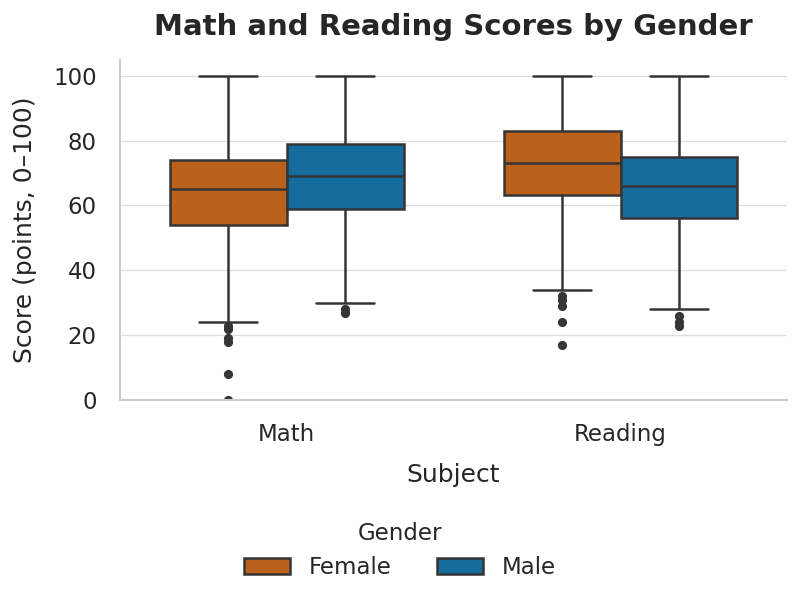

In [ ]:
def v1_gender_boxplots(df: pd.DataFrame) -> dict:
    long = df.melt(id_vars="gender", value_vars=["math_score", "reading_score"],
                   var_name="subject", value_name="score")
    long["subject"] = long["subject"].map({"math_score": "Math", "reading_score": "Reading"})
    long["gender"] = long["gender"].astype(str).str.capitalize()
    palette = {k.capitalize(): v for k, v in GENDER_COLORS.items()}

    fig, ax = new_fig()
    sns.boxplot(data=long, x="subject", y="score", hue="gender", hue_order=["Female", "Male"],
                palette=palette, width=0.7, linewidth=0.6, fliersize=1.2, ax=ax)
    ax.set(title="Math and Reading Scores by Gender", xlabel="Subject",
           ylabel=f"Score ({UNITS})", ylim=(0, 105))
    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()
    fig.legend(handles, labels, title="Gender", loc="outside lower center", ncol=2, frameon=False)
    save(fig, "v1")

    f = df[df.gender == "female"]
    m = df[df.gender == "male"]
    out = {"n_f": len(f), "n_m": len(m)}
    for s in ["math_score", "reading_score"]:
        t = stats.ttest_ind(m[s], f[s], equal_var=False)
        out[s] = {
            "f_mean": f[s].mean(), "m_mean": m[s].mean(),
            "f_med": f[s].median(), "m_med": m[s].median(),
            "f_sd": f[s].std(), "m_sd": m[s].std(),
            "diff_m_minus_f": m[s].mean() - f[s].mean(),
            "p": t.pvalue, "d": cohens_d(m[s], f[s]),
        }
    return out


st["v1"] = v1_gender_boxplots(df)
display(Image(filename=str(FIG_PATHS["v1"])))

### V2 - Test preparation impact on math

*Question:* Do students who completed test prep score higher in math?

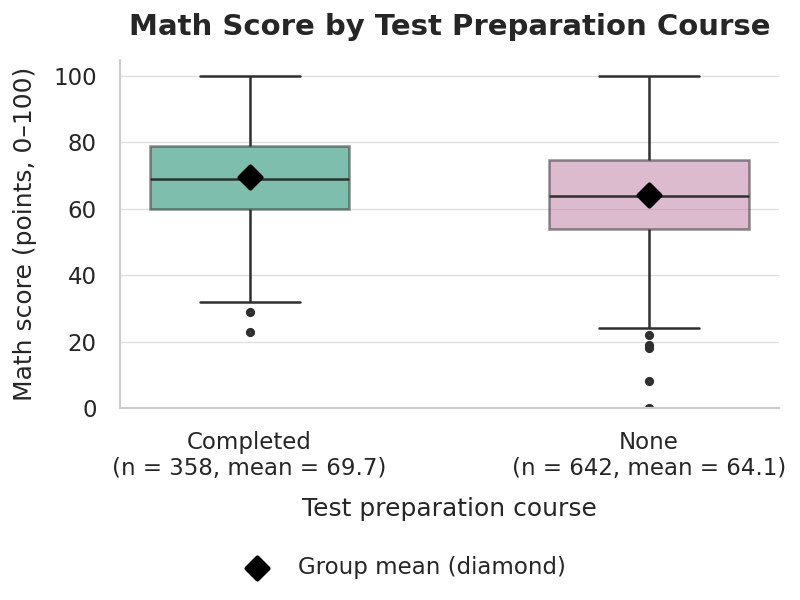

In [ ]:
def v2_test_prep_math(df: pd.DataFrame) -> dict:
    order = ["completed", "none"]
    counts = df["test_prep"].value_counts()
    gmean = df.groupby("test_prep", observed=True)["math_score"].mean()
    labels = {k: f"{k.capitalize()}\n(n = {counts[k]}, mean = {gmean[k]:.1f})" for k in order}
    plot_df = df.assign(prep_label=df["test_prep"].astype(str).map(labels))

    fig, ax = new_fig()
    sns.boxplot(data=plot_df, x="prep_label", y="math_score", order=[labels[k] for k in order],
                hue="prep_label", palette={labels[k]: PREP_COLORS[k] for k in order}, legend=False,
                width=0.5, linewidth=0.6, fliersize=1.2, boxprops={"alpha": 0.55}, ax=ax)
    means = [df.loc[df.test_prep == k, "math_score"].mean() for k in order]
    ax.scatter([0, 1], means, marker="D", s=14, color="black", zorder=5, label="Group mean (diamond)")
    ax.set(title="Math Score by Test Preparation Course", xlabel="Test preparation course",
           ylabel=f"Math score ({UNITS})", ylim=(0, 105))
    handles, lbls = ax.get_legend_handles_labels()
    fig.legend(handles, lbls, loc="outside lower center", frameon=False)
    save(fig, "v2")

    a = df.loc[df.test_prep == "completed", "math_score"]
    b = df.loc[df.test_prep == "none", "math_score"]
    t = stats.ttest_ind(a, b, equal_var=False)
    return {"n_c": len(a), "n_n": len(b), "mean_c": a.mean(), "mean_n": b.mean(),
            "med_c": a.median(), "med_n": b.median(), "sd_c": a.std(), "sd_n": b.std(),
            "diff": a.mean() - b.mean(), "p": t.pvalue, "d": cohens_d(a, b),
            "min_c": int(a.min()), "min_n": int(b.min()),
            "share_n_below_50": float((b < 50).mean()), "share_c_below_50": float((a < 50).mean())}


st["v2"] = v2_test_prep_math(df)
display(Image(filename=str(FIG_PATHS["v2"])))

### V3 - Lunch type and average performance

*Question:* Does lunch type (standard vs free/reduced) relate to outcomes?
Grouped bars show the mean math, reading, writing and overall average (`overall_avg`) for each lunch type.

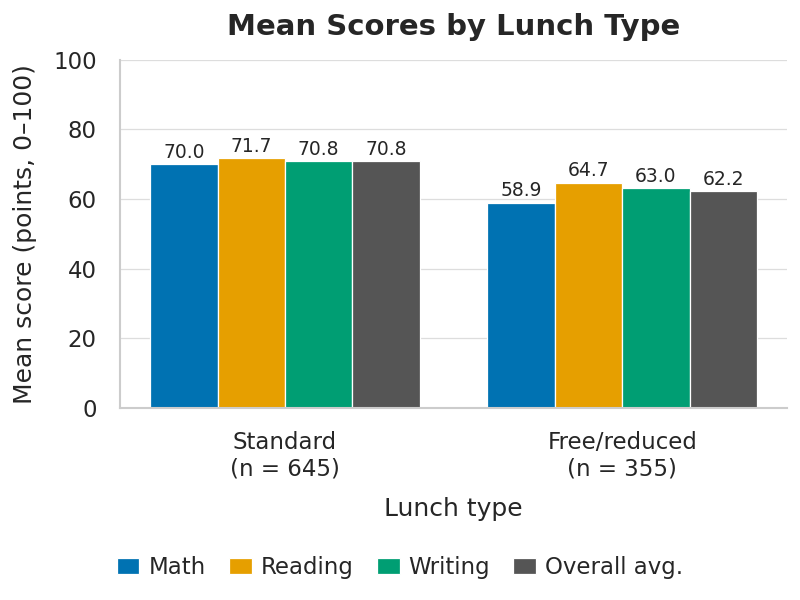

In [ ]:
def v3_lunch_average(df: pd.DataFrame) -> dict:
    cols = {"math_score": "Math", "reading_score": "Reading",
            "writing_score": "Writing", "overall_avg": "Overall avg."}
    means = df.groupby("lunch", observed=True)[list(cols)].mean()
    counts = df["lunch"].value_counts()
    order = ["standard", "free/reduced"]

    fig, ax = new_fig()
    width = 0.2
    x = np.arange(len(order))
    for i, (col, name) in enumerate(cols.items()):
        vals = [means.loc[k, col] for k in order]
        bars = ax.bar(x + (i - 1.5) * width, vals, width, label=name, color=SUBJECT_COLORS[i],
                      edgecolor="white", linewidth=0.3)
        for bar, v in zip(bars, vals):
            ax.annotate(f"{v:.1f}", (bar.get_x() + bar.get_width() / 2, v), xytext=(0, 1.5),
                        textcoords="offset points", ha="center", fontsize=4.5)
    ax.set_xticks(x, [f"{k.capitalize()}\n(n = {counts[k]})" for k in order])
    ax.set(title="Mean Scores by Lunch Type", xlabel="Lunch type",
           ylabel=f"Mean score ({UNITS})", ylim=(0, 100))
    ax.grid(axis="x", visible=False)
    handles, lbls = ax.get_legend_handles_labels()
    fig.legend(handles, lbls, loc="outside lower center", ncol=4, frameon=False,
               handlelength=1.0, columnspacing=1.0, handletextpad=0.4)
    save(fig, "v3")

    s = df.loc[df.lunch == "standard", "overall_avg"]
    fr = df.loc[df.lunch == "free/reduced", "overall_avg"]
    t = stats.ttest_ind(s, fr, equal_var=False)
    out = {"n_s": len(s), "n_f": len(fr), "p": t.pvalue, "d": cohens_d(s, fr)}
    for col in cols:
        out[col] = {"standard": means.loc["standard", col], "free": means.loc["free/reduced", col],
                    "gap": means.loc["standard", col] - means.loc["free/reduced", col]}
    return out


st["v3"] = v3_lunch_average(df)
display(Image(filename=str(FIG_PATHS["v3"])))

### V4 - Subject correlations

*Question:* How strongly do the three subjects move together?

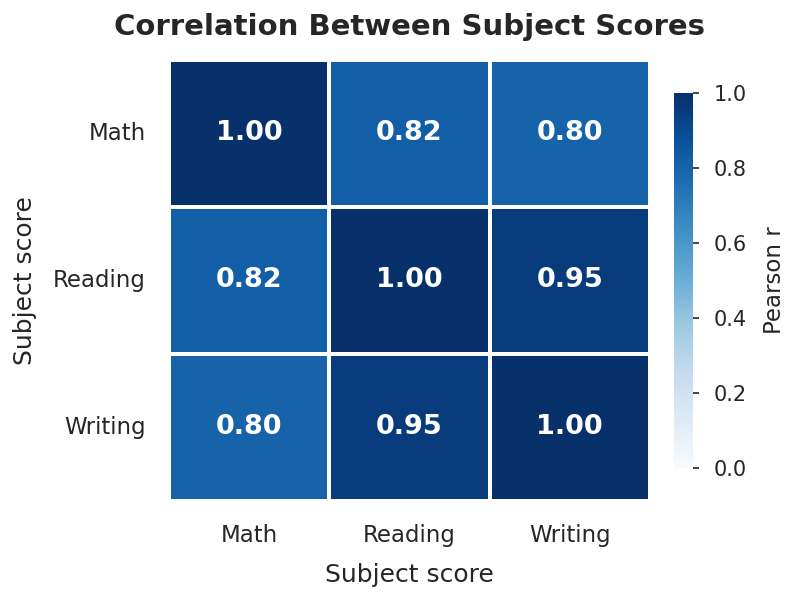

In [ ]:
def v4_subject_correlations(df: pd.DataFrame) -> dict:
    cols = ["math_score", "reading_score", "writing_score"]
    names = ["Math", "Reading", "Writing"]
    corr = df[cols].corr()
    corr.index, corr.columns = names, names

    fig, ax = new_fig()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, linewidths=0.5,
                annot_kws={"size": 6.5, "fontweight": "bold"},
                cbar_kws={"label": "Pearson r", "shrink": 0.85}, ax=ax)
    ax.figure.axes[-1].tick_params(labelsize=5, width=0.4, length=1.5)
    ax.figure.axes[-1].yaxis.label.set_size(5.5)
    ax.set(title="Correlation Between Subject Scores", xlabel="Subject score", ylabel="Subject score")
    ax.tick_params(axis="y", rotation=0)
    ax.grid(False)
    save(fig, "v4")
    return {"mr": corr.loc["Math", "Reading"], "mw": corr.loc["Math", "Writing"],
            "rw": corr.loc["Reading", "Writing"]}


st["v4"] = v4_subject_correlations(df)
display(Image(filename=str(FIG_PATHS["v4"])))

### V5 - Math vs reading with trend lines by test prep

*Question:* How strongly are math and reading associated, and do test-prep completers have a different slope?

One least-squares line per group. The slope difference is tested with an interaction model
(`math ~ reading + prep + reading:prep`, plain OLS in NumPy).

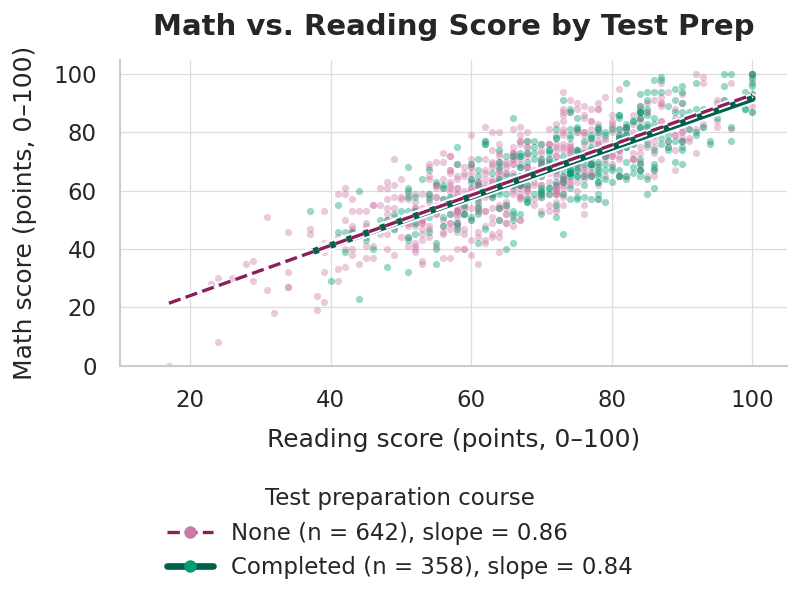

In [ ]:
def v5_math_vs_reading(df: pd.DataFrame) -> dict:
    fig, ax = new_fig()
    handles, res = [], {}
    for grp in ["none", "completed"]:  # draw the larger group first so both stay visible
        d = df[df.test_prep == grp]
        color = PREP_COLORS[grp]
        ls = "--" if grp == "none" else "-"
        lr = stats.linregress(d["reading_score"], d["math_score"])
        ax.scatter(d["reading_score"], d["math_score"], s=3, alpha=0.4, color=color,
                   linewidths=0, zorder=2)
        xs = np.array([d["reading_score"].min(), d["reading_score"].max()])
        lw = 1.6 if grp == "completed" else 0.8  # thick solid under thin dashed: both stay visible
        ax.plot(xs, lr.intercept + lr.slope * xs, color=PREP_LINE_COLORS[grp], linewidth=lw,
                linestyle=ls, zorder=4 if grp == "completed" else 5,
                path_effects=[pe.withStroke(linewidth=lw + 0.9, foreground="white")])
        handles.append(Line2D([0], [0], color=PREP_LINE_COLORS[grp], marker="o", markersize=3,
                              markerfacecolor=color, markeredgewidth=0, linewidth=lw, linestyle=ls,
                              label=f"{grp.capitalize()} (n = {len(d)}), slope = {lr.slope:.2f}"))
        res[grp] = {"n": len(d), "slope": lr.slope, "intercept": lr.intercept, "r": lr.rvalue,
                    "r2": lr.rvalue ** 2, "se_slope": lr.stderr}
    ax.set(title="Math vs. Reading Score by Test Prep", xlabel=f"Reading score ({UNITS})",
           ylabel=f"Math score ({UNITS})", xlim=(10, 105), ylim=(0, 105))
    fig.legend(handles=handles, title="Test preparation course", loc="outside lower center",
               ncol=1, frameon=False)
    save(fig, "v5")

    # Slope-difference test: math ~ reading + completed + reading:completed (plain OLS)
    comp = (df["test_prep"] == "completed").astype(float).to_numpy()
    x = df["reading_score"].to_numpy(dtype=float)
    y = df["math_score"].to_numpy(dtype=float)
    X = np.column_stack([np.ones(len(df)), x, comp, x * comp])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    dof = len(y) - X.shape[1]
    cov = (resid @ resid / dof) * np.linalg.inv(X.T @ X)
    t_int = beta[3] / np.sqrt(cov[3, 3])
    all_lr = stats.linregress(df["reading_score"], df["math_score"])
    x70 = 70
    res["interaction"] = {"diff": beta[3], "se": float(np.sqrt(cov[3, 3])),
                          "t": float(t_int), "p": float(2 * stats.t.sf(abs(t_int), dof)), "dof": dof}
    res["overall"] = {"r": all_lr.rvalue, "r2": all_lr.rvalue ** 2, "slope": all_lr.slope}
    res["pred70"] = {g: res[g]["intercept"] + res[g]["slope"] * x70 for g in ["completed", "none"]}
    return res


st["v5"] = v5_math_vs_reading(df)
display(Image(filename=str(FIG_PATHS["v5"])))

## Interpretations and report

Each interpretation is generated from the computed statistics (nothing typed in by hand), and direction-dependent
wording is guarded by `assert`s so the text cannot silently contradict the data. The report writer also checks
that every interpretation has 5-8 sentences.

In [ ]:
def fp(p: float) -> str:
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

def n_sentences(text: str) -> int:
    return len([s for s in re.split(r"(?<=[.!?])\s+", text.strip()) if s])

def interpretations(df: pd.DataFrame, st: dict) -> dict[str, str]:
    v1, v2, v3, v4, v5 = (st[k] for k in ["v1", "v2", "v3", "v4", "v5"])
    m, r = v1["math_score"], v1["reading_score"]

    # ---- guards for direction-dependent wording
    assert m["m_mean"] > m["f_mean"] and r["f_mean"] > r["m_mean"]
    assert v2["mean_c"] > v2["mean_n"]
    assert all(v3[c]["gap"] > 0 for c in ["math_score", "reading_score", "writing_score", "overall_avg"])
    assert v3["math_score"]["gap"] > max(v3["reading_score"]["gap"], v3["writing_score"]["gap"])
    assert v4["rw"] > max(v4["mr"], v4["mw"])
    assert v5["interaction"]["p"] > 0.05

    f_min_math = int(df.loc[df.gender == "female", "math_score"].min())
    m_min_math = int(df.loc[df.gender == "male", "math_score"].min())
    q = df.groupby("test_prep", observed=True)["math_score"].quantile([0.25, 0.75]).unstack()
    read_by_prep = df.groupby("test_prep", observed=True)["reading_score"].mean()
    it = v5["interaction"]

    v1_text = (
        f"The boxplots show a crossover: males have the higher math distribution, while females have the higher reading distribution. "
        f"In math the male median is {m['m_med']:.0f} versus {m['f_med']:.0f} for females (means {m['m_mean']:.1f} versus {m['f_mean']:.1f}, "
        f"a {m['diff_m_minus_f']:.1f}-point gap). "
        f"In reading the pattern reverses: the female median is {r['f_med']:.0f} versus {r['m_med']:.0f} for males "
        f"(means {r['f_mean']:.1f} versus {r['m_mean']:.1f}, a {abs(r['diff_m_minus_f']):.1f}-point female advantage). "
        f"Both gaps are statistically significant (Welch t-test, {fp(max(m['p'], r['p']))}), but the effect sizes are only small to moderate "
        f"(Cohen's d = {abs(m['d']):.2f} for math and {abs(r['d']):.2f} for reading). "
        f"The boxes have similar heights and the standard deviations are all between {min(m['f_sd'], m['m_sd'], r['f_sd'], r['m_sd']):.1f} and "
        f"{max(m['f_sd'], m['m_sd'], r['f_sd'], r['m_sd']):.1f} points, so gender shifts the whole distribution rather than changing its spread. "
        f"The boxes still overlap heavily, so a student's gender says little about an individual score, and every group has low outliers "
        f"(the lowest math scores are {f_min_math} for females and {m_min_math} for males). "
        f"These are descriptive differences only and cannot say whether curriculum, test design, or other factors are responsible."
    )

    v2_text = (
        f"Students who completed the test preparation course scored higher in math on average: a mean of {v2['mean_c']:.1f} versus {v2['mean_n']:.1f}, "
        f"a difference of {v2['diff']:.1f} points (medians {v2['med_c']:.0f} versus {v2['med_n']:.0f}). "
        f"The whole box sits higher for the completed group, with a middle 50% of {q.loc['completed', 0.25]:.0f} to {q.loc['completed', 0.75]:.0f} "
        f"compared with {q.loc['none', 0.25]:.0f} to {q.loc['none', 0.75]:.0f} for the group with no preparation. "
        f"The difference is statistically significant (Welch t-test, {fp(v2['p'])}), but the effect size is small to moderate (Cohen's d = {v2['d']:.2f}). "
        f"The low tail is heavier without preparation: {v2['share_n_below_50']:.1%} of those students scored below 50 compared with "
        f"{v2['share_c_below_50']:.1%} of completers, and the lowest scores are {v2['min_n']} versus {v2['min_c']}. "
        f"The spreads are similar (standard deviations {v2['sd_c']:.1f} and {v2['sd_n']:.1f}) and the distributions overlap a lot, "
        f"so many students without preparation outscore students who completed it. "
        f"Because students chose whether to take the course, motivation or resources could explain part of the gap, so this is an association rather than proof that the course raises scores."
    )

    g = {c: v3[c] for c in ["math_score", "reading_score", "writing_score", "overall_avg"]}
    v3_text = (
        f"Students with standard lunch outperform those with free/reduced lunch in every subject, and the overall average is "
        f"{g['overall_avg']['standard']:.1f} versus {g['overall_avg']['free']:.1f}, a gap of {g['overall_avg']['gap']:.1f} points. "
        f"The gap is widest in math ({g['math_score']['gap']:.1f} points) and narrower in reading ({g['reading_score']['gap']:.1f}) and writing "
        f"({g['writing_score']['gap']:.1f}), and math is the weakest subject for the free/reduced group at {g['math_score']['free']:.1f}. "
        f"The difference in overall average is statistically significant (Welch t-test, {fp(v3['p'])}) and the effect size is moderate to large "
        f"(Cohen's d = {v3['d']:.2f}), larger than the gender and test-preparation effects in the earlier figures. "
        f"The groups are unequal in size ({v3['n_s']} standard versus {v3['n_f']} free/reduced), and the bars show means only, so the spread within each group is not visible here. "
        f"Lunch type is commonly used as a proxy for family income, so the pattern probably reflects broader socioeconomic conditions rather than the meal itself. "
        f"The comparison is unadjusted for other variables such as parental education or test preparation, so it should be read as an association, not a cause."
    )

    v4_text = (
        f"All three subject scores are positively and strongly correlated, with coefficients from {min(v4['mr'], v4['mw']):.2f} to {v4['rw']:.2f}. "
        f"Reading and writing are almost interchangeable (r = {v4['rw']:.2f}); they share about {v4['rw'] ** 2:.0%} of their variance, "
        f"which fits the idea that both draw on the same language skills. "
        f"Math is strongly related to reading (r = {v4['mr']:.2f}) and to writing (r = {v4['mw']:.2f}), but these correspond to only about "
        f"{v4['mr'] ** 2:.0%} and {v4['mw'] ** 2:.0%} shared variance, so roughly a third of the variation in math is not explained by the other subjects. "
        f"Overall the pattern suggests a general academic-performance factor: a student who does well in one subject usually does well in the others. "
        f"Because reading and writing are so highly correlated, using both as predictors of math would add little beyond using either one. "
        f"Pearson's r captures only linear association and does not show that one skill causes another."
    )

    v5_text = (
        f"Reading and math scores are strongly and positively associated (overall r = {v5['overall']['r']:.2f}), so reading score alone accounts for about "
        f"{v5['overall']['r2']:.0%} of the variation in math score. "
        f"Each additional reading point goes with roughly {v5['overall']['slope']:.2f} additional math points across all students. "
        f"The fitted slopes for the two groups are almost the same: {v5['completed']['slope']:.2f} for students who completed the course "
        f"(n = {v5['completed']['n']}) and {v5['none']['slope']:.2f} for those who did not (n = {v5['none']['n']}). "
        f"A formal interaction test finds no evidence that the slopes differ (difference {it['diff']:+.3f} with standard error {it['se']:.3f}, {fp(it['p'])}). "
        f"The two lines nearly coincide: at a reading score of 70 they predict math scores of {v5['pred70']['completed']:.1f} (completed) and "
        f"{v5['pred70']['none']:.1f} (none), a difference of under one point. "
        f"Completers do have higher reading scores on average ({read_by_prep['completed']:.1f} versus {read_by_prep['none']:.1f}), so most of their math advantage in the previous figure "
        f"lines up with where they sit on the same math-reading line rather than a separate boost at equal reading level. "
        f"The relationship is similarly tight within each group (r = {v5['completed']['r']:.2f} and {v5['none']['r']:.2f}). "
        f"This is observational data, and the line intercepts should not be interpreted because a reading score of zero lies far outside the observed range."
    )
    return {"v1": v1_text, "v2": v2_text, "v3": v3_text, "v4": v4_text, "v5": v5_text}

SECTIONS = {
    "v1": ("V1 - Gender boxplots (math vs reading)",
           "Are there gender differences in math vs reading?",
           "Side-by-side boxplots of math and reading scores, grouped by gender.",
           "v1_gender_boxplots.png"),
    "v2": ("V2 - Test preparation impact on math",
           "Do students who completed test prep score higher in math?",
           "Boxplots of math score by test preparation course (completed vs none); diamonds mark the group means.",
           "v2_test_prep_math.png"),
    "v3": ("V3 - Lunch type and average performance",
           "Does lunch type (standard vs free/reduced) relate to outcomes?",
           "Grouped bar chart of mean math, reading, writing and overall average (mean of the three) by lunch type.",
           "v3_lunch_average.png"),
    "v4": ("V4 - Subject correlations",
           "How strongly do the three subjects move together?",
           "Correlation heatmap (Pearson r) with annotated coefficients.",
           "v4_subject_correlations.png"),
    "v5": ("V5 - Math vs reading with trend lines by test prep",
           "How strongly are math and reading associated, and do test-prep completers have a different slope?",
           "Scatter plot (x = reading score, y = math score), coloured by test preparation course, with one least-squares line per group; legend shows each group's n and slope.",
           "v5_math_vs_reading_by_prep.png"),
}

In [ ]:
def write_report(raw_info: dict, log: dict, df: pd.DataFrame, st: dict) -> dict[str, str]:
    texts = interpretations(df, st)
    for k, t in texts.items():
        n = n_sentences(t)
        assert 5 <= n <= 8, f"{k} interpretation has {n} sentences (needs 5-8)"

    missing_rows = "\n".join(f"| {c} | {raw_info['missing_per_column'][c]} |" for c in raw_info["missing_per_column"])
    out = f"""# Q2 - Students Performance: preprocessing and visualization findings

Workflow (`student_performance.ipynb`): ingest (load + integrity checks) -> preprocess (clean, validate,
derive `overall_avg`) -> analyze (statistics + figures + this report).
Every figure is **800 x 600 px at 300 DPI** (2.67 x 2.00 in) with a title, labelled axes with units,
and a legend where applicable.

## 1. Ingestion and preprocessing

**Ingestion.** `data/raw/StudentsPerformance.csv` loaded with pandas: {raw_info['rows']} rows x {raw_info['cols']} columns
(gender, race/ethnicity, parental level of education, lunch, test preparation course, math / reading / writing score).
The raw file is never modified.

**Missing values (raw file), count per column:**

| Column | Missing |
|---|---|
{missing_rows}

**Cleaning decisions (the preprocessing code also handles cases not present in this file):**

| Step | Rule | Result on this dataset |
|---|---|---|
| Column names | renamed to snake_case (`test_prep`, `math_score`, ...) | done |
| Text categories | trimmed and lower-cased so categories cannot split on case or spaces | done |
| Scores | forced to numeric; non-numeric becomes missing | all values already numeric |
| Missing categorical | filled with `"unknown"` | 0 values needed filling |
| Missing scores | row dropped (imputing a score would distort the plotted quantity) | {log['rows_dropped_missing_score']} rows dropped |
| Duplicate rows | dropped | {log['duplicates_dropped']} dropped |
| Range check | scores must lie in 0-100 | {log['out_of_range_dropped']} out-of-range rows |
| Outliers | flagged with the 1.5 x IQR rule but **kept**: they are valid low scores (minimums: math {log['lowest_scores']['math_score']}, reading {log['lowest_scores']['reading_score']}, writing {log['lowest_scores']['writing_score']}) | math {log['iqr_outliers_kept']['math_score']}, reading {log['iqr_outliers_kept']['reading_score']}, writing {log['iqr_outliers_kept']['writing_score']} flagged |
| Derived column | `overall_avg` = mean of math, reading and writing, rounded to 2 dp | added |

Final analysis table: **{log['rows_out']} rows** saved to `data/processed/students_clean.csv`.
Group sizes: {int((df.gender == 'female').sum())} female / {int((df.gender == 'male').sum())} male;
{int((df.test_prep == 'completed').sum())} completed test prep / {int((df.test_prep == 'none').sum())} none;
{int((df.lunch == 'standard').sum())} standard lunch / {int((df.lunch == 'free/reduced').sum())} free/reduced lunch.

## 2. Visualizations and interpretations
"""
    for k, (title, question, chart, fname) in SECTIONS.items():
        out += f"""
### {title}

**Question:** {question}
**Chart:** {chart}

![{title}](../figures/{fname})

**Interpretation.** {texts[k]}
"""
    out += f"""
## 3. Conclusion

Three patterns stand out across the five figures. Gender is a trade-off, not a one-sided advantage:
males score higher in math and females higher in reading (V1). Preparation and background both line
up with higher scores: completing test prep adds {st['v2']['diff']:.1f} points in math (V2), and standard
lunch adds {st['v3']['overall_avg']['gap']:.1f} points overall (V3), the larger of the two gaps. The three
subjects move together (V4), and test-prep completers score higher in math mainly because they read
better, not because their math-reading relationship has a different slope (V5). All of this is
observational: it shows association, not proof that any one factor causes another.
"""
    REPORT.parent.mkdir(parents=True, exist_ok=True)
    REPORT.write_text(out, encoding="utf-8")
    return texts


texts = write_report(raw_info, log, df, st)
for k, t in texts.items():
    print(f"{k}: {n_sentences(t)} sentences")
print("Report written to", REPORT.relative_to(ROOT))

v1: 7 sentences
v2: 6 sentences
v3: 6 sentences
v4: 6 sentences
v5: 8 sentences
Report written to reports/findings.md


## Final check - figure specification

In [ ]:
for key, path in FIG_PATHS.items():
    with PILImage.open(path) as im:
        assert im.size == (800, 600), f"{path.name} is {im.size}, expected (800, 600)"
        print(f"{path.name}: {im.size[0]}x{im.size[1]} px, {round(im.info['dpi'][0])} DPI")

v1_gender_boxplots.png: 800x600 px, 300 DPI
v2_test_prep_math.png: 800x600 px, 300 DPI
v3_lunch_average.png: 800x600 px, 300 DPI
v4_subject_correlations.png: 800x600 px, 300 DPI
v5_math_vs_reading_by_prep.png: 800x600 px, 300 DPI


## Conclusion

In [ ]:
print(
    "Across all five figures, three patterns stand out:\n"
    "1. Gender: males score higher in math, females score higher in reading (V1) - a trade-off, "
    "not a one-sided advantage.\n"
    f"2. Preparation and background: test-prep completion (+{st['v2']['diff']:.1f} pts in math, V2) and "
    f"standard lunch (+{st['v3']['overall_avg']['gap']:.1f} pts overall, V3) both line up with higher "
    "scores; the lunch gap is the larger of the two.\n"
    "3. Subjects move together: math, reading and writing are all strongly correlated (V4), and the "
    "math-reading relationship is essentially the same line for both test-prep groups (V5) - prepared "
    "students score higher mainly because they read better, not because of a different slope.\n"
    "All of this is observational: it shows association, not proof that any one factor causes another."
)

Across all five figures, three patterns stand out:
1. Gender: males score higher in math, females score higher in reading (V1) - a trade-off, not a one-sided advantage.
2. Preparation and background: test-prep completion (+5.6 pts in math, V2) and standard lunch (+8.6 pts overall, V3) both line up with higher scores; the lunch gap is the larger of the two.
3. Subjects move together: math, reading and writing are all strongly correlated (V4), and the math-reading relationship is essentially the same line for both test-prep groups (V5) - prepared students score higher mainly because they read better, not because of a different slope.
All of this is observational: it shows association, not proof that any one factor causes another.
